<img src="logos/Logo_de_la_Facultad_Experimental_de_Ciencia_y_Tecnología.svg.png"
     width="250"
     style="display: block; margin-left: auto; margin-right: auto;">

<div align="center">

**UNIVERSIDAD DE CARABOBO**
Facultad Experimental de Ciencia y Tecnología
Departamento de Computación
Electiva: Aprendizaje Automático

# Minecraft Composting EDA
### Exploratory Data Analysis — Assignment 1

</div>

**Professor:** Álvaro Espinoza &nbsp;|&nbsp; **Course:** Aprendizaje Automático &nbsp;|&nbsp; **Year:** 2026

---

## Purpose

This notebook presents a complete, reproducible exploratory data analysis (EDA). Its goal is
to understand the dataset's structure, quality, and patterns *before* building a predictive model — not to
prove causality or make final modeling decisions. It aims to:

- detect data quality issues;
- describe distributions and relationships;
- formulate hypotheses;
- acknowledge uncertainty and limitations;
- propose decisions that must later be validated.

**Unit of observation:** one simulated composting attempt (one item addition), reconstructed in Section 8 from the session totals given in the raw files.  
**Target variable:** `level_increased` (`0` = did not raise the compost level, `1` = raised it).  
**Downstream problem type:** binary classification.

**Problem description.** In Minecraft, a *composter* block converts organic items into bone meal. Every
time a compostable item is added, there is an item-specific probability that the compost level rises by
one. Once the composter reaches its maximum level it becomes *ready*, and the next addition yields bone
meal. The prediction task this dataset is meant to support is:
*given a single composting attempt (one item addition), predict whether that attempt will raise the
composter's level.*

The raw data we are given, however, is not already at that granularity: 16 CSV files (one per material,
3,000 trials each) record **session totals** — how many item-units a full session consumed before the
composter became ready — not individual attempt outcomes. Reconciling this gap is itself part of this
EDA (Section 8): we first analyze the data at the granularity it was given in (session totals), then
reconstruct the attempt-level table the actual prediction task needs, and show how differently the
"baseline" looks depending on which granularity is used.



# 1. Context and Problem Definition

**Domain.** Each source file corresponds to one compostable material in Minecraft (e.g. apples, cactus,
wheat seeds). A file contains 3,000 independent simulated "sessions": in each session, the material is
added to an empty composter repeatedly until the composter becomes ready. The single column in each file
records how many item-units that took.

**Two granularities in play.** The project's stated target task for this dataset is explicit: predict
whether a composting attempt will be successful. An **attempt** is a single item addition — not a full
session. This matters because it does not match the granularity of the raw files:

- **Session level** (as directly provided): one row = one full composting session for one material, ending
  when the composter becomes ready. Feature: `items_used`, the number of item-units consumed.
- **Attempt level** (the course's actual prediction unit, reconstructed in Section 8): one row = one single
  item addition. Label: `level_increased`, whether that specific addition raised the compost level.

This EDA works at the session level first (Sections 4–7), since that is what the raw files literally
contain and it is directly informative about how materials differ. Section 8 then reconstructs the
attempt-level table, since that is the unit the stated prediction task actually needs.

**Target variable.** The variable the course intends to predict is `level_increased` (binary: 1 if a given
attempt raised the compost level, 0 otherwise) — a **binary classification problem**. We also analyze a
secondary, session-level target, `quick_fill` (Section 9, secondary target): whether a session finished within a fixed item
budget. It is kept because it offers a complementary, player-facing framing of the same underlying process,
but `level_increased` is the one aligned with the course's stated target.

**Classes.** Both `level_increased` and `quick_fill` are binary (0/1). `material` is a 16-class nominal
variable used throughout as a **predictor**, never as a target.



# 2. Guiding Questions

1. What materials does the dataset contain, and what does each column represent once combined?
2. Are there missing values, duplicated identifiers, or values that are impossible under the composting
   mechanic (e.g. counts below the theoretical minimum)?
3. How is `items_used` distributed, overall and per material?
4. Do materials cluster into distinct behavioral groups (fast fillers vs. slow fillers), and how strongly
   does `material` associate with fill speed?
5. The course's stated prediction task operates on individual composting attempts, not full sessions — how
   can we reconstruct attempt-level records from the session totals we are given, and what does that
   reconstruction assume?
6. Is the reconstructed attempt-level target (`level_increased`) — or the alternative session-level
   `quick_fill` — meaningfully associated with material identity, and do other groupings (e.g. seed vs.
   non-seed) add information beyond material alone?
7. What derived variables better expose structure in the data for a later modeling stage?

> Even a strong association between `material` and success is a property of this simulated sample, not proof
> that no other feature could ever matter — see the causality discussion in Section 10.



# 3. Configuration and Reproducibility


In [1]:

# --- Imports -----------------------------------------------------------
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# --- Reproducibility -----------------------------------------------------
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# --- Data location (reproducible; works whether launched from the repo ---
# --- root or from the notebooks/ directory, e.g. VS Code vs. Jupyter Lab) -
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_DIR = PROJECT_ROOT / "data"
assert DATA_DIR.exists(), f"Expected data directory at {DATA_DIR.resolve()}"

# --- Display / plotting options -------------------------------------------
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titleweight"] = "bold"

warnings.filterwarnings("ignore", category=FutureWarning)



# 4. Loading the Unified Dataset (Session Level)

The raw data ships as 16 separate CSV files under `data/`, one per material, each with a single column
named after the material (e.g. `Apples`, `Cacti`) and no explicit identifier. Unifying those 16 files into
one table is **prior work, done once, before this EDA** — a small standalone script (`build_dataset.py`,
run from the project root) reads all 16 files, derives a clean `material` label from each file name, adds a
synthetic `trial_id` (0..2999) since the raw files carry no identifier of their own, and concatenates them
into a single long-format table: one row per composting session, columns `material`, `trial_id`,
`items_used`. There is no join key between the 16 files — each is an independent sample for a different
material — so that script concatenates rather than joins, and checks that no file is silently dropped and
no rows are lost or duplicated in the process.

This notebook does not repeat that step. It reads the single result directly:


In [2]:

composting = pd.read_csv(DATA_DIR / "composting_combined.csv")
print(f"Loaded data/composting_combined.csv -> {len(composting):,} rows, {composting['material'].nunique()} materials.")
composting.head()


Loaded data/composting_combined.csv -> 48,000 rows, 16 materials.


,material,trial_id,items_used
0,Apple,0,10
1,Apple,1,10
2,Apple,2,10
3,Apple,3,11
4,Apple,4,12


In [3]:

# --- Confirm the unified file matches the expected shape -----------------
assert list(composting.columns) == ["material", "trial_id", "items_used"]
assert len(composting) == 48_000, "Unexpected row count in composting_combined.csv"
assert composting["material"].nunique() == 16, "Unexpected number of distinct materials"
assert composting.duplicated(subset=["material", "trial_id"]).sum() == 0, "Duplicate (material, trial_id) key"
print("Shape and key checks on the loaded file passed.")


Shape and key checks on the loaded file passed.



**Conclusion.** `data/composting_combined.csv` has the expected shape — 48,000 rows (16 materials × 3,000
trials), a unique `(material, trial_id)` key, and matches the session-level unit of observation declared in
Section 1. Everything from here on works from this one file.



# 5. Structural Inspection and Analytical Roles

Pandas dtype and **analytical role** are not the same thing: `trial_id` is stored as an integer but acts as
an identifier, not a measure.

| Column | Stored dtype | Analytical role |
|---|---|---|
| `material` | object (string) | categorical, nominal (16 levels) — main predictor |
| `trial_id` | int64 | identifier (per-material sequence number, not a measure) |
| `items_used` | int64 | numeric, discrete (count of item-units) — base continuous variable |

The original per-file provenance (which raw CSV each material came from) belongs to the prior unification
step (`build_dataset.py`, Section 4), not to this table — it was only needed to verify that construction,
not to describe an actual session.


In [4]:

print("Shape:", composting.shape)
print()
print("Dtypes:")
print(composting.dtypes)
print()
print("Missing values per column:")
print(composting.isna().sum())
print()
print("Unique values per column:")
print(composting.nunique())


Shape: (48000, 3)

Dtypes:
material        str
trial_id      int64
items_used    int64
dtype: object

Missing values per column:
material      0
trial_id      0
items_used    0
dtype: int64

Unique values per column:
material        16
trial_id      3000
items_used      52
dtype: int64



**Conclusion.** The table has 3 columns and 48,000 rows, no missing values in any column, `material` has
exactly 16 unique values as expected, and `items_used` takes far fewer unique values than there are rows
(it is a small-range discrete count, not a continuous measurement or an identifier in disguise).



# 6. Data Quality

We check, in turn: missing values, duplicated rows/keys, domain-range validity, cardinality, outliers, and
row order — distinguishing legitimate extreme values from likely errors.


### Missing values

In [5]:

missing = composting.isna().sum().to_frame("n_missing")
missing["pct_missing"] = (missing["n_missing"] / len(composting) * 100).round(3)
missing


,n_missing,pct_missing
material,0,0.000
trial_id,0,0.000
items_used,0,0.000



**Conclusion.** There are zero missing values in any column. This is expected for a synthetic simulation
output (every trial necessarily ends with a recorded count), unlike most real-world tabular data — a point
we revisit in the limitations section, since it means this dataset cannot be used to study missingness
mechanisms.


### Duplicates

In [6]:

full_row_dupes = composting.duplicated(subset=["material", "items_used"], keep=False).sum()
key_dupes = composting.duplicated(subset=["material", "trial_id"]).sum()

print(f"Rows sharing the same (material, items_used) value: {full_row_dupes:,} "
      f"out of {len(composting):,} ({full_row_dupes/len(composting):.1%})")
print(f"Duplicate (material, trial_id) identifiers: {key_dupes}")

# How many distinct items_used values does each material actually take?
composting.groupby("material")["items_used"].nunique().sort_values().to_frame("n_distinct_values")


Rows sharing the same (material, items_used) value: 47,963 out of 48,000 (99.9%)
Duplicate (material, trial_id) identifiers: 0


,n_distinct_values
material,
Cookie,9
Apple,15
Pumpkin,15
Potato,15
Wheat,16
Radish,16
Carrot,16
Melon,16
Cactus,22



**Conclusion.** A large share of rows share the same `(material, items_used)` combination — but this is
**not a data quality problem**. `items_used` is a bounded discrete count (each material only takes a
handful of distinct values across 3,000 trials), so repeated values are the expected result of sampling the
same small-support distribution many times, not duplicated observations. The identifier-level check is the
one that matters here, and it confirms zero duplicate `(material, trial_id)` keys.


### Domain-range validity

In [7]:

range_summary = composting.groupby("material")["items_used"].agg(["min", "max"]).sort_values("min")
print("Global minimum items_used:", composting["items_used"].min())
print("Any non-positive or impossible (<7) values?",
      (composting["items_used"] < 7).any())
range_summary


Global minimum items_used: 7
Any non-positive or impossible (<7) values? False


,min,max
material,,
Apple,7,21
Cactus,7,28
Carrot,7,22
Cookie,7,15
Melon,7,22
Melon Seeds,7,55
Oak Leaves,7,57
Oak Sapling,7,56
Potato,7,21



**Conclusion.** Every material has a minimum of exactly 7 item-units across 3,000 trials, and no value ever
falls below that floor. This matches the composting mechanic: reaching the "ready" state requires a fixed
number of *successful* additions, so no session can finish in fewer than that many items even if every
single addition succeeds. This floor of 7 is the key fact Section 8 relies on to reconstruct attempt-level
records. No impossible or negative values are present.


### Cardinality

In [8]:

print("Distinct materials:", composting["material"].nunique(), "/ 16 expected")
composting["material"].value_counts()


Distinct materials: 16 / 16 expected


material
Apple            3000
Cactus           3000
Carrot           3000
Cookie           3000
Melon            3000
Melon Seeds      3000
Oak Leaves       3000
Oak Sapling      3000
Potato           3000
Pumpkin          3000
Pumpkin Seeds    3000
Radish           3000
Radish Seeds     3000
Sugar Cane       3000
Wheat            3000
Wheat Seeds      3000
Name: count, dtype: int64


**Conclusion.** All 16 materials are present with exactly 3,000 trials each — a perfectly balanced design
by construction. There are no rare categories, typos, or inconsistent labels to consolidate.


### Outliers

In [9]:

def iqr_outlier_share(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    upper = q3 + 1.5 * iqr
    return (s > upper).mean()

outlier_share = composting.groupby("material")["items_used"].apply(iqr_outlier_share).sort_values(ascending=False)
outlier_share.to_frame("share_above_iqr_upper_fence")


,share_above_iqr_upper_fence
material,
Wheat,0.048
Pumpkin,0.047
Potato,0.047
Radish,0.047
Wheat Seeds,0.022
Sugar Cane,0.021
Pumpkin Seeds,0.018
Oak Sapling,0.017
Melon Seeds,0.016



**Conclusion.** Every material shows some IQR-flagged "outliers" on the high side, at roughly the rate
expected for a right-skewed distribution — these are **not errors**. Because each addition succeeds
randomly, a session can in principle run long by chance (a long streak of failed additions); the far right
tail is a legitimate, if less common, outcome rather than a data error. This is confirmed later by the
shape of the per-material distributions (Section 7) and is the motivation for a log transform in
Section 11.


### Sequence/order check

The assignment's guidance on temporal and sequential data asks us to check whether row order carries
information, and to avoid treating an ordered sequence as freely shuffleable. Rows within each source file
have a natural order (`trial_id`, the position in that file). There is no reason to expect the 3,000
composting sessions for a material to be temporally linked — but this should be **verified, not assumed**:
if the simulation had any warm-up effect, seed cycling, or drift, later trials could differ systematically
from earlier ones.


In [10]:

order_check = []
for material, g in composting.groupby("material"):
    corr = g["items_used"].corr(g["trial_id"])
    half = len(g) // 2
    first_half_mean = g["items_used"].iloc[:half].mean()
    second_half_mean = g["items_used"].iloc[half:].mean()
    order_check.append({
        "material": material,
        "corr(items_used, trial_id)": corr,
        "first_half_mean": first_half_mean,
        "second_half_mean": second_half_mean,
    })
pd.DataFrame(order_check).set_index("material").sort_values("corr(items_used, trial_id)")


,"corr(items_used, trial_id)",first_half_mean,second_half_mean
material,,,
Sugar Cane,-0.089,13.445,12.899
Carrot,-0.036,10.326,10.230
Cactus,-0.027,13.085,12.930
Pumpkin Seeds,-0.020,21.147,21.119
Apple,-0.016,10.289,10.198
Pumpkin,-0.011,10.271,10.195
Radish,-0.009,10.222,10.215
Melon Seeds,-0.003,21.121,20.984
Oak Leaves,-0.003,20.927,20.950



**Conclusion.** For every material, the correlation between `items_used` and row position is negligible
(all within ±0.09), and the mean of the first half of trials is essentially identical to the mean of the
second half. This supports treating each material's 3,000 trials as **independent and identically
distributed** draws, with no drift or ordering effect — so, unlike a genuine time series, shuffling these
rows would not discard any information, and no special temporal handling (e.g. chronological splitting) is
required for this dataset. This i.i.d. assumption is also what justifies the reconstruction in Section 8.


### Data quality synthesis — and why no cleaning is applied here

Consolidating the checks above: **zero missing values, zero duplicate identifiers, no impossible or out-of-range
values, a perfectly balanced 16×3,000 design, no drift across trial order, and the only "outliers" present
are legitimate long-tail draws of a right-skewed process, not errors.** There is, in short, no quality
problem in this dataset that calls for cleaning.

This matters because the assignment is explicit that this EDA is **not** the place to clean data even if
issues existed: *"No se deben eliminar o imputar observaciones de manera automática ni sin justificación"*
and *"Las decisiones finales de preprocesamiento no se consideran demostradas por el EDA"* — any imputer,
encoder, or scaler must instead be fit later, only on the training split. Concretely, this means:

- **No rows are dropped and no values are imputed anywhere in this notebook.**
- Where a quality check *could* have suggested an action (e.g. the IQR "outliers" check above), we instead
  diagnosed *why* the values are legitimate rather than removing them.
- The only preprocessing-relevant output of this section is a set of **hypotheses for the modeling stage**
  (Section 12): encode `material` via `probability_tier`, consider `log_items_used` for regression framings,
  and fit any such transform only on training data. There is no cleaning or imputation hypothesis to add,
  because none of the checks above found anything that needs cleaning or imputing.



# 7. Univariate Analysis (Session Level)


In [11]:

composting["material"].value_counts().sort_index().to_frame("n_trials")


,n_trials
material,
Apple,3000
Cactus,3000
Carrot,3000
Cookie,3000
Melon,3000
Melon Seeds,3000
Oak Leaves,3000
Oak Sapling,3000
Potato,3000


In [12]:

overall_stats = composting["items_used"].describe(percentiles=[.25, .5, .75, .9, .99]).to_frame("items_used")
overall_stats.loc["skew"] = composting["items_used"].skew()
overall_stats


,items_used
count,"48,000.000"
mean,14.488
std,6.930
min,7.000
25%,9.000
50%,12.000
75%,18.000
90%,25.000
99%,36.000
max,73.000


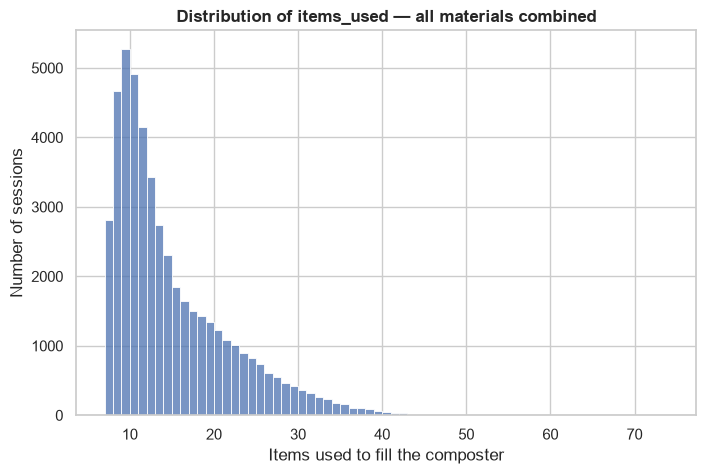

In [13]:

fig, ax = plt.subplots()
sns.histplot(composting["items_used"], bins=range(7, composting["items_used"].max() + 2), ax=ax)
ax.set_title("Distribution of items_used — all materials combined")
ax.set_xlabel("Items used to fill the composter")
ax.set_ylabel("Number of sessions")
plt.show()



**Conclusion.** Pooled across all materials, `items_used` is strongly **right-skewed**: most sessions
finish quickly, but a long tail of sessions requires many more items. This is exactly the shape expected
from a mixture of several "how many tries until success" processes with different success probabilities —
which is why we look at each material separately next.


In [14]:

per_material_stats = (
    composting.groupby("material")["items_used"]
    .agg(n="count", mean="mean", std="std", median="median", skew="skew", min="min", max="max")
    .sort_values("mean")
)
per_material_stats


,n,mean,std,median,skew,min,max
material,,,,,,,
Cookie,3000,8.035,1.101,8.000,1.246,7,15
Radish,3000,10.218,2.256,10.000,1.001,7,23
Potato,3000,10.229,2.206,10.000,0.936,7,21
Pumpkin,3000,10.233,2.259,10.000,0.933,7,21
Wheat,3000,10.243,2.250,10.000,1.052,7,22
Apple,3000,10.243,2.239,10.000,0.956,7,21
Carrot,3000,10.278,2.256,10.000,0.912,7,22
Melon,3000,10.303,2.286,10.000,0.937,7,22
Cactus,3000,13.007,3.484,12.000,0.835,7,28


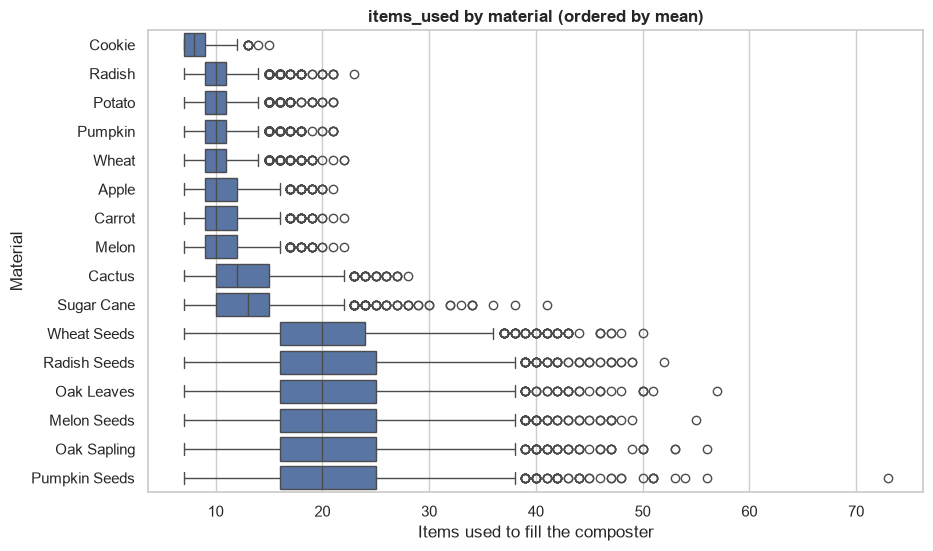

In [15]:

order = per_material_stats.index.tolist()
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=composting, y="material", x="items_used", order=order, ax=ax)
ax.set_title("items_used by material (ordered by mean)")
ax.set_xlabel("Items used to fill the composter")
ax.set_ylabel("Material")
plt.show()



**Conclusion.** Materials separate into visibly distinct bands rather than forming one continuum: `Cookie`
fills fastest (mean ≈ 8 items), a large group of common crops (`Apple`, `Carrot`, `Melon`, `Potato`,
`Pumpkin`, `Radish`, `Wheat`) clusters tightly around a mean of ≈ 10 items, `Cactus` and `Sugar Cane` sit
around a mean of ≈ 13 items, and all seeds together with `Oak Leaves`/`Oak Sapling` need over 20 items on
average. Within each of these bands the materials are hard to tell apart — a redundancy we formalize as an
engineered "probability tier" variable in Section 10. Sample sizes are equal (3,000) for every material, so
none of these comparisons rest on small groups.



# 8. Reconstructing Attempt-Level Records (the Course's Actual Prediction Unit)

Sections 4–7 worked at the granularity the raw files provide: one row per full session. But the course's
stated prediction task is defined per **attempt** (one item addition). This section builds that table from
the session totals, states the assumptions this requires explicitly, and validates the result.


### Why this is needed, and what it assumes

From the domain-range check earlier in Section 6, every session's minimum possible length is exactly 7 items, and that minimum is reached
only if *every single addition succeeds*. This means every session — regardless of material or length —
consists of **exactly 7 successful attempts and `items_used - 7` failed attempts**, and the very last
attempt in a session is always a success (that is what ends the session).

What the raw data does **not** tell us is *where*, among the failed attempts, those 7 successes occurred
(only the total `items_used` is recorded). To reconstruct one plausible attempt-by-attempt sequence per
session, we rely on the i.i.d. assumption already validated earlier in Section 6: since each attempt is an
independent Bernoulli trial with a fixed per-material success probability, conditional on a session ending
at length `N`, the other 6 successes (besides the guaranteed final one) are **uniformly distributed** among
the first `N - 1` attempts. We simulate one such uniformly-random placement per session using a fixed seed.

**This makes the within-session order in the reconstructed table synthetic, not observed.** Any feature
that would depend on that specific order (e.g. "number of failures immediately before this attempt") would
be fabricated, not measured, and must not be treated as real signal in later modeling.


In [16]:

SUCCESSES_REQUIRED = int(composting["items_used"].min())
assert SUCCESSES_REQUIRED == 7, "Unexpected minimum items_used; reconstruction logic assumes 7"
print(f"Every session requires exactly {SUCCESSES_REQUIRED} successful attempts (confirmed earlier in Section 6).")


Every session requires exactly 7 successful attempts (confirmed earlier in Section 6).


### Building the attempt-level table

In [17]:

sessions = (
    composting[["material", "trial_id", "items_used"]]
    .rename(columns={"trial_id": "session_id"})
    .reset_index(drop=True)
)
sessions["global_session_id"] = np.arange(len(sessions))

n_attempts_total = int(sessions["items_used"].sum())
print(f"Total reconstructed attempts across all {len(sessions):,} sessions: {n_attempts_total:,}")

# One row per attempt, expanded from each session's length.
attempts = pd.DataFrame({
    "material": np.repeat(sessions["material"].values, sessions["items_used"].values),
    "session_id": np.repeat(sessions["global_session_id"].values, sessions["items_used"].values),
    "session_length": np.repeat(sessions["items_used"].values, sessions["items_used"].values),
    "attempt_number": np.concatenate([np.arange(1, n + 1) for n in sessions["items_used"].values]),
})

is_last_attempt = attempts["attempt_number"] == attempts["session_length"]

# Randomly place the remaining (SUCCESSES_REQUIRED - 1) successes among the non-final attempts
# of each session (uniform, per the exchangeability argument above). Seeded for reproducibility.
rng = np.random.default_rng(RANDOM_STATE)
rand_key = pd.Series(rng.random(len(attempts)), index=attempts.index)
rand_key[is_last_attempt] = np.nan  # excluded from ranking below

rank_within_session = rand_key[~is_last_attempt].groupby(attempts.loc[~is_last_attempt, "session_id"]).rank(method="first")

extra_successes_needed = SUCCESSES_REQUIRED - 1
attempts["level_increased"] = 0
attempts.loc[is_last_attempt, "level_increased"] = 1
attempts.loc[rank_within_session[rank_within_session <= extra_successes_needed].index, "level_increased"] = 1

attempts = attempts.drop(columns=["session_length"])
attempts.head(10)


Total reconstructed attempts across all 48,000 sessions: 695,423


,material,session_id,attempt_number,level_increased
0,Apple,0,1,1
1,Apple,0,2,1
2,Apple,0,3,0
3,Apple,0,4,1
4,Apple,0,5,1
5,Apple,0,6,0
6,Apple,0,7,1
7,Apple,0,8,0
8,Apple,0,9,1
9,Apple,0,10,1


### Validating the reconstruction

In [18]:

successes_per_session = attempts.groupby("session_id")["level_increased"].sum()

assert len(attempts) == n_attempts_total, "Attempt count does not match sum of items_used"
assert (successes_per_session == SUCCESSES_REQUIRED).all(), "Some session does not have exactly 7 successes"
print(f"Reconstructed attempts table: {attempts.shape[0]:,} rows, {attempts.shape[1]} columns.")
print(f"Every one of the {len(successes_per_session):,} sessions has exactly {SUCCESSES_REQUIRED} successes: confirmed.")


Reconstructed attempts table: 695,423 rows, 4 columns.
Every one of the 48,000 sessions has exactly 7 successes: confirmed.



**Conclusion.** The reconstruction is internally consistent by construction (every session sums to exactly
7 successes, and the total row count matches the sum of `items_used`). This table's shape — one row per
attempt, binary `level_increased` label — is exactly the unit of observation the course's stated prediction
task needs, even though it had to be derived rather than read directly from the raw files.


### Per-material success probability

Collapsing the attempt-level table by material recovers each material's estimated per-attempt success
probability, `p_hat` — the single most important quantity for the course's actual prediction task.


In [19]:

p_hat_table = (
    attempts.groupby("material")["level_increased"]
    .agg(n_attempts="size", p_hat="mean")
    .sort_values("p_hat", ascending=False)
)
p_hat_table["se"] = np.sqrt(p_hat_table["p_hat"] * (1 - p_hat_table["p_hat"]) / p_hat_table["n_attempts"])

# Cross-check against the session-level statistic: p_hat should closely match SUCCESSES_REQUIRED / mean(items_used).
cross_check = per_material_stats.assign(p_from_session_mean=lambda d: SUCCESSES_REQUIRED / d["mean"])
p_hat_table.join(cross_check[["p_from_session_mean"]]).sort_values("p_hat", ascending=False)


,n_attempts,p_hat,se,p_from_session_mean
material,,,,
Cookie,24104,0.871,0.002,0.871
Radish,30655,0.685,0.003,0.685
Potato,30687,0.684,0.003,0.684
Pumpkin,30700,0.684,0.003,0.684
Wheat,30730,0.683,0.003,0.683
Apple,30730,0.683,0.003,0.683
Carrot,30834,0.681,0.003,0.681
Melon,30908,0.679,0.003,0.679
Cactus,39022,0.538,0.003,0.538


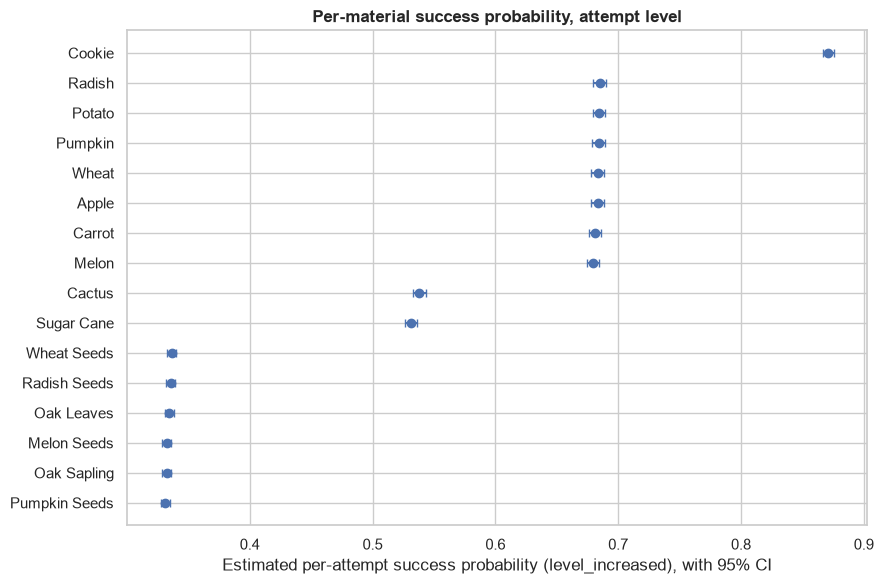

In [20]:

order = p_hat_table.sort_values("p_hat").index
y_pos = np.arange(len(order))
vals = p_hat_table.loc[order, "p_hat"]
errs = 1.96 * p_hat_table.loc[order, "se"]

fig, ax = plt.subplots(figsize=(9, 6))
ax.errorbar(vals, y_pos, xerr=errs, fmt="o", color="#4C72B0", capsize=3)
ax.set_yticks(y_pos)
ax.set_yticklabels(order)
ax.set_xlabel("Estimated per-attempt success probability (level_increased), with 95% CI")
ax.set_title("Per-material success probability, attempt level")
plt.tight_layout()
plt.show()



**Conclusion.** `p_hat` (computed directly from the reconstructed attempt-level table) matches
`SUCCESSES_REQUIRED / mean(items_used)` (computed from the original session-level data) almost exactly for
every material — as it must, since both are two ways of measuring the same underlying quantity. **This
reconstruction does not create new information**; it repackages the session-level means into the correct
table *shape* for the course's actual prediction task. The confidence intervals are extremely narrow
because each material contributes thousands to tens of thousands of attempts, so these probability
estimates are precise. This is the central quantity Section 9 uses to state the attempt-level target's
class balance.



# 9. Target Variable(s)


### Primary target — `level_increased` (attempt level)

`level_increased` (built in Section 8) is the target aligned with the course's stated task: given a single
composting attempt, will it raise the compost level?


In [21]:

overall_p = attempts["level_increased"].mean()
print(f"Overall attempt-level success rate (baseline): {overall_p:.1%}")
print(f"Naive majority-class baseline accuracy for level_increased: {max(overall_p, 1 - overall_p):.1%}")


Overall attempt-level success rate (baseline): 48.3%
Naive majority-class baseline accuracy for level_increased: 51.7%



**Conclusion — and an important contrast.** At the attempt level, the pooled success rate is only about
48%, essentially a coin flip (majority-class baseline ≈ 52%). This is dramatically different from the
session-level `quick_fill_20` baseline computed in Section 9 (the secondary, session-level target, ≈ 82%). The reason is **not** a
contradiction: slower materials (lower `p_hat`) contribute far more *attempts* per session (a "Slow fill"
session averages ~21 attempts vs. `Cookie`'s ~8), so pooling at the attempt level weights the data heavily
toward those harder-to-satisfy attempts, while pooling at the session level treats every session equally
regardless of how many attempts it took. **The choice of unit of observation changes what "balanced" or
"imbalanced" even means for this problem** — a fact worth remembering before quoting any single "class
balance" number for this dataset without saying which granularity it refers to.


### Secondary target — `quick_fill` (session level)

As a complementary, player-facing framing, we also define a binary target directly on the session totals:
`quick_fill = 1` if a session finished using at most `K` items, else `0` — "if I only have `K` units of this
material, will the composter finish?" We inspect `K = 10` and `K = 20`; as the percentile check below shows,
`K = 10` sits near the pooled distribution's 25th–35th percentile (a strict budget) and `K = 20` near its
80th percentile (a lenient budget), so together they span a strict and a lenient reading of "success". This
threshold is a modeling hypothesis, not a validated requirement — it should be revisited once the exact
downstream use case is defined.


In [22]:

pooled_percentiles = composting["items_used"].quantile([.1, .25, .5, .75, .8, .9])
print("Pooled items_used percentiles:")
print(pooled_percentiles)
print()
print(f"Share of ALL sessions (any material) with items_used <= 10: {(composting['items_used'] <= 10).mean():.1%}")
print(f"Share of ALL sessions (any material) with items_used <= 20: {(composting['items_used'] <= 20).mean():.1%}")


Pooled items_used percentiles:
0.100    8.000
0.250    9.000
0.500   12.000
0.750   18.000
0.800   20.000
0.900   25.000
Name: items_used, dtype: float64

Share of ALL sessions (any material) with items_used <= 10: 36.8%
Share of ALL sessions (any material) with items_used <= 20: 81.9%


In [23]:

for K in (10, 20):
    composting[f"quick_fill_{K}"] = (composting["items_used"] <= K).astype(int)

baseline_20 = composting["quick_fill_20"].mean()
baseline_10 = composting["quick_fill_10"].mean()
print(f"Overall quick_fill_10 success rate (baseline): {baseline_10:.1%}")
print(f"Overall quick_fill_20 success rate (baseline): {baseline_20:.1%}")
print()
print("Naive majority-class baseline accuracy for quick_fill_20:",
      f"{max(baseline_20, 1 - baseline_20):.1%}")


Overall quick_fill_10 success rate (baseline): 36.8%
Overall quick_fill_20 success rate (baseline): 81.9%

Naive majority-class baseline accuracy for quick_fill_20: 81.9%


In [24]:

success_by_material = (
    composting.groupby("material")[["quick_fill_10", "quick_fill_20"]]
    .mean()
    .sort_values("quick_fill_20")
)
success_by_material


,quick_fill_10,quick_fill_20
material,,
Pumpkin Seeds,0.022,0.522
Oak Leaves,0.029,0.524
Melon Seeds,0.027,0.525
Wheat Seeds,0.026,0.534
Oak Sapling,0.027,0.538
Radish Seeds,0.030,0.539
Sugar Cane,0.251,0.959
Cactus,0.259,0.967
Radish,0.605,0.998


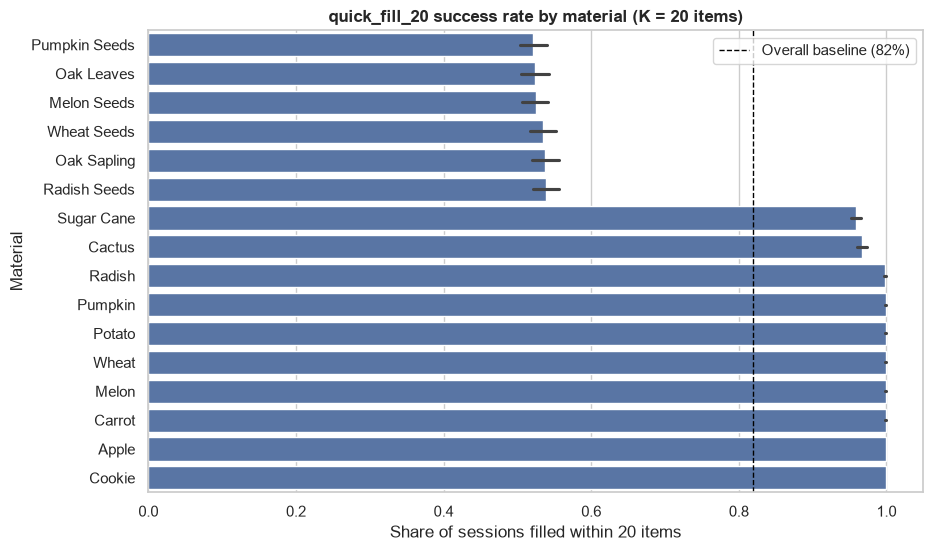

In [25]:

fig, ax = plt.subplots(figsize=(10, 6))
order = success_by_material.index.tolist()
sns.barplot(data=composting, y="material", x="quick_fill_20", order=order, ax=ax, color="#4C72B0")
ax.axvline(baseline_20, color="black", linestyle="--", linewidth=1, label=f"Overall baseline ({baseline_20:.0%})")
ax.set_title("quick_fill_20 success rate by material (K = 20 items)")
ax.set_xlabel("Share of sessions filled within 20 items")
ax.set_ylabel("Material")
ax.legend()
plt.show()



**Conclusion.** At `K = 20`, materials split almost entirely into two extremes: the crop group
(`Cookie`, `Apple`, `Carrot`, `Melon`, `Potato`, `Pumpkin`, `Radish`, `Wheat`, `Cactus`, `Sugar Cane`)
succeeds nearly 100% of the time, while seeds, `Oak Leaves`, and `Oak Sapling` succeed roughly half the
time (consistent with their mean of ≈ 21, right at the boundary). `K = 10` is far stricter and mostly
only `Cookie` clears it reliably. As with `level_increased`, **`material` alone is almost sufficient to
predict `quick_fill`** — an important point we return to in Section 12, since it affects what a
"predictive model" would actually be learning under either target.



# 10. Bivariate and Multivariate Analysis

**Scope note.** `items_used` is the only continuous variable measured directly in this dataset — every
other column is either an identifier or derived from `material` itself. Classic continuous-vs-continuous
techniques (scatterplots, a correlation matrix, checks for nonlinear relationships between two measured
quantities) therefore do not apply here. What *does* apply, and is the focus of this section, is
quantifying how strongly `material` (and groupings built from it) associates with `items_used` /
`quick_fill`, and whether some of those groupings are redundant with each other. This section works at the
session level, since that is where the richest per-material comparisons are; its conclusions (redundancy,
tiering) apply equally to the attempt-level target, since `level_increased` is deterministically linked to
the same per-material probabilities (Section 8).


### Data-driven probability tiers (redundancy among materials)

Section 7 showed materials clustering into bands rather than a continuum. Instead of relying on outside
knowledge of the game's item probabilities, we derive the grouping directly from the data: sort materials
by their empirical mean `items_used`, and split at the largest gaps between consecutive means.


In [26]:

sorted_means = per_material_stats["mean"].sort_values()
gaps = sorted_means.diff()
# 3 largest gaps -> 4 clusters
cut_after = gaps.sort_values(ascending=False).head(3).index
cut_positions = sorted(sorted_means.index.get_loc(m) for m in cut_after)

tier_labels = ["Very fast fill", "Fast fill", "Moderate fill", "Slow fill"]
material_order = sorted_means.index.tolist()
boundaries = [0] + cut_positions + [len(material_order)]
material_to_tier = {}
for i in range(len(boundaries) - 1):
    for m in material_order[boundaries[i]:boundaries[i + 1]]:
        material_to_tier[m] = tier_labels[i]

composting["probability_tier"] = composting["material"].map(material_to_tier)
composting["probability_tier"] = pd.Categorical(composting["probability_tier"], categories=tier_labels, ordered=True)

tier_table = (
    composting.groupby("probability_tier", observed=True)
    .agg(materials=("material", lambda s: ", ".join(sorted(s.unique()))),
         n=("material", "size"),
         mean_items_used=("items_used", "mean"))
)
tier_table


,materials,n,mean_items_used
probability_tier,,,
Very fast fill,Cookie,3000,8.035
Fast fill,"Apple, Carrot, Melon, Potato, Pumpkin, Radish,...",21000,10.250
Moderate fill,"Cactus, Sugar Cane",6000,13.089
Slow fill,"Melon Seeds, Oak Leaves, Oak Sapling, Pumpkin ...",18000,20.974


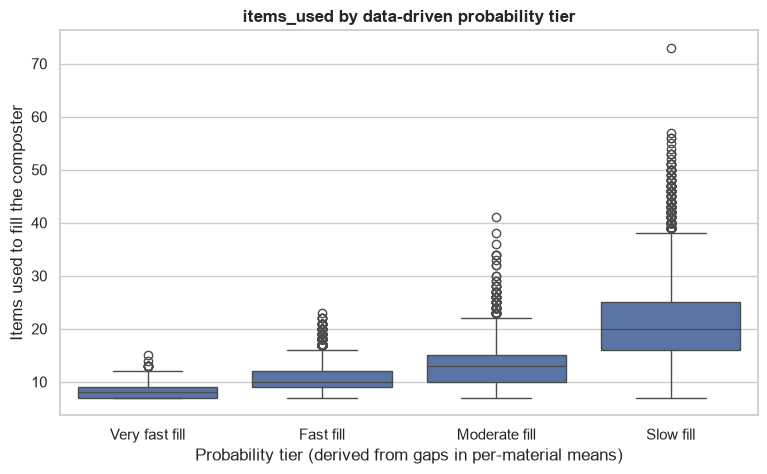

In [27]:

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=composting, x="probability_tier", y="items_used", ax=ax)
ax.set_title("items_used by data-driven probability tier")
ax.set_xlabel("Probability tier (derived from gaps in per-material means)")
ax.set_ylabel("Items used to fill the composter")
plt.show()



**Conclusion.** The gap-based split recovers 4 tiers that separate cleanly with almost no overlap between
adjacent boxes, confirming that materials genuinely fall into a small number of behavioral groups rather
than varying individually. Within a tier, materials are close to statistically redundant for the purpose of
predicting `items_used` — a modeling implication we revisit in Section 12 (encoding `material` via its tier
may be preferable to full one-hot encoding of 16 levels).

*Domain cross-check (not used to derive the tiers, only to sanity-check them):* these four data-driven
groups line up with Minecraft's publicly documented composter chance categories for these items (roughly
30%, 50%, 65%, and 85% per addition, from slowest to fastest tier). We did not use these published
percentages to build `probability_tier` — it comes purely from gaps in the *observed* means — but the match
is a useful confirmation that the clustering reflects a real, known mechanism rather than sampling noise.


### Quantifying redundancy: does the tier lose information vs. full material detail?

The boxplots above suggest `probability_tier` (4 levels) captures most of what 16-level `material` explains
about `items_used`. We check this quantitatively with an eta-squared effect size (share of variance in
`items_used` explained by group membership) for both groupings, plus a Kruskal-Wallis test as a
non-parametric check that the groups differ at all (appropriate here since `items_used` is discrete and
right-skewed, not normally distributed).


In [28]:

def eta_squared(frame, group_col, value_col="items_used"):
    grand_mean = frame[value_col].mean()
    ss_between = frame.groupby(group_col)[value_col].apply(
        lambda g: len(g) * (g.mean() - grand_mean) ** 2
    ).sum()
    ss_total = ((frame[value_col] - grand_mean) ** 2).sum()
    return ss_between / ss_total

h_stat, p_value = stats.kruskal(*[g["items_used"].values for _, g in composting.groupby("material")])

eta_material = eta_squared(composting, "material")
eta_tier = eta_squared(composting, "probability_tier")

print(f"Kruskal-Wallis across 16 materials: H = {h_stat:,.1f}, p = {p_value:.3g}")
print(f"Eta-squared, material (16 levels) -> items_used: {eta_material:.4f}")
print(f"Eta-squared, probability_tier (4 levels) -> items_used: {eta_tier:.4f}")
print(f"Variance explained retained by collapsing to 4 tiers: {eta_tier / eta_material:.1%}")


Kruskal-Wallis across 16 materials: H = 30,269.7, p = 0
Eta-squared, material (16 levels) -> items_used: 0.5516
Eta-squared, probability_tier (4 levels) -> items_used: 0.5515
Variance explained retained by collapsing to 4 tiers: 100.0%



**Conclusion.** The Kruskal-Wallis test confirms materials differ significantly (expected at n = 48,000 —
the p-value alone is not very informative at this sample size, which is why effect size matters more here).
The eta-squared values are the key result: the 4-level `probability_tier` explains essentially the **same**
share of variance in `items_used` as the full 16-level `material` variable (over 99.9% of it retained).
This is quantitative confirmation, not just a visual impression, that `probability_tier` is a safe,
low-cardinality replacement for `material` with negligible information loss.


### Relative variability across tiers

Beyond the mean, we check whether the *relative* spread (coefficient of variation, `std / mean`) also
differs systematically by tier, or whether it is roughly constant (which would suggest a single simple
scaling relationship between mean and variance across all materials).


In [29]:

cv_table = per_material_stats.assign(cv=lambda d: d["std"] / d["mean"])[["mean", "std", "cv"]]
cv_table["probability_tier"] = cv_table.index.map(material_to_tier)
cv_table.sort_values("mean")


,mean,std,cv,probability_tier
material,,,,
Cookie,8.035,1.101,0.137,Very fast fill
Radish,10.218,2.256,0.221,Fast fill
Potato,10.229,2.206,0.216,Fast fill
Pumpkin,10.233,2.259,0.221,Fast fill
Wheat,10.243,2.250,0.220,Fast fill
Apple,10.243,2.239,0.219,Fast fill
Carrot,10.278,2.256,0.220,Fast fill
Melon,10.303,2.286,0.222,Fast fill
Cactus,13.007,3.484,0.268,Moderate fill



**Conclusion.** The coefficient of variation is *not* constant — it rises from about 0.14 for `Cookie`
(fastest tier) to about 0.32 for the seed/leaf/sapling tier (slowest tier), and materials within the same
tier again match each other closely (e.g. all seed materials sit within 0.32–0.33). So slower-filling
materials are not just larger on average, they are also **relatively** more variable — consistent with a
lower per-addition success probability producing a heavier-tailed "tries until success" process. This
reinforces, via a second and independent statistic, that the tier grouping reflects a real underlying
generative difference rather than an artifact of comparing means alone.


### Seed vs. non-seed materials

As a second, semantically-motivated grouping (independent of the empirical tiers above), we flag whether a
material's name indicates a seed.


In [30]:

composting["is_seed"] = composting["material"].str.contains("Seed").map({True: "Seed", False: "Non-seed"})

seed_summary = (
    composting.groupby("is_seed", observed=True)
    .agg(n=("items_used", "size"),
         mean_items_used=("items_used", "mean"),
         quick_fill_20_rate=("quick_fill_20", "mean"))
)
seed_summary


,n,mean_items_used,quick_fill_20_rate
is_seed,,,
Non-seed,36000,12.330,0.915
Seed,12000,20.961,0.530



**Conclusion.** Seeds need roughly twice as many items on average as non-seed materials, and their
`quick_fill_20` success rate is far lower. This matches the tier finding above (all four seed materials
fall in the "Slow fill" tier) — the two groupings are consistent rather than contradictory, but `is_seed`
is coarser (2 levels vs. 4) and cheaper to compute from the raw material name alone.


### Interaction: tier × seed indicator on success rate

`Oak Leaves` and `Oak Sapling` are in the "Slow fill" tier but are *not* seeds, while all seeds are also in
that tier. We check whether `is_seed` adds anything on top of `probability_tier`, or whether it is fully
redundant with it.


In [31]:

interaction = (
    composting.groupby(["probability_tier", "is_seed"], observed=True)
    .agg(n=("items_used", "size"), quick_fill_20_rate=("quick_fill_20", "mean"))
)
interaction


n  quick_fill_20_rate
probability_tier is_seed                            
Very fast fill   Non-seed   3000               1.000
Fast fill        Non-seed  21000               0.999
Moderate fill    Non-seed   6000               0.963
Slow fill        Non-seed   6000               0.531
                 Seed      12000               0.530

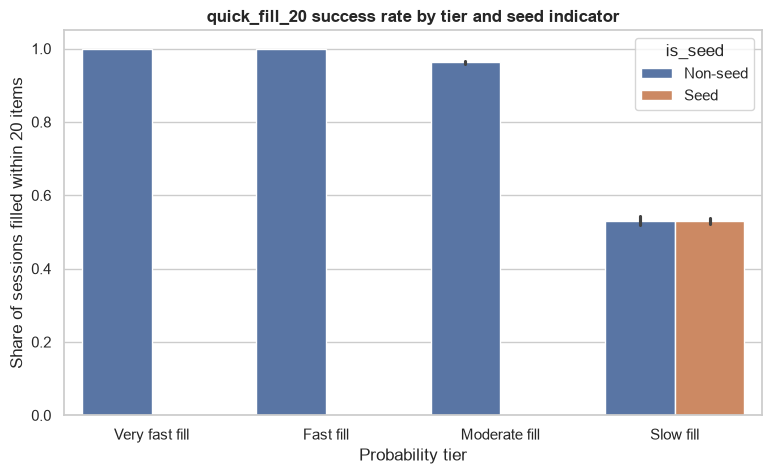

In [32]:

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=composting, x="probability_tier", y="quick_fill_20", hue="is_seed", ax=ax)
ax.set_title("quick_fill_20 success rate by tier and seed indicator")
ax.set_xlabel("Probability tier")
ax.set_ylabel("Share of sessions filled within 20 items")
plt.show()



**Conclusion.** `is_seed` only exists as a distinct category within the "Slow fill" tier (where it splits
into `Oak Leaves`/`Oak Sapling` vs. the four seed materials), and within that tier the two groups have
similar success rates — so `is_seed` adds little once `probability_tier` (or `material` itself) is known.
This is an example of **redundancy between predictors** rather than a useful interaction, worth noting so a
later model doesn't treat both as independently informative.


### Association vs. causality

`material` is *assigned by construction* in this synthetic dataset — the simulation, not the observed
outcome, determines which material a trial belongs to. The strong association between `material`/
`probability_tier` and `items_used`/`quick_fill`/`level_increased` therefore does reflect a genuine causal
mechanism (each material's fixed success probability drives how many additions it takes), not a spurious
correlation or confound. This is an unusually clean case for causal reasoning precisely because the dataset
is simulated; real observational data would need much more caution before making the same claim.



# 11. Exploratory Feature Engineering

Beyond `probability_tier`, `is_seed`, and `level_increased` / `p_hat` (already introduced above because
they were needed for the target and bivariate analyses), we construct one more variable: a log transform of
`items_used`, motivated by its right skew.


### `log_items_used`

- **Definition:** `log_items_used = log(items_used)`.
- **Intuition:** the composting process is fundamentally multiplicative (each item is an independent
  "chance", and the count is a stopping time), so its natural scale is closer to logarithmic than linear;
  a log transform should reduce skew and stabilize variance across the very different tiers.
- **Limitation:** compresses the differences between the fast tiers (7-15 range) more than it should for
  some downstream uses, and makes the variable harder to interpret directly in "number of items" terms.


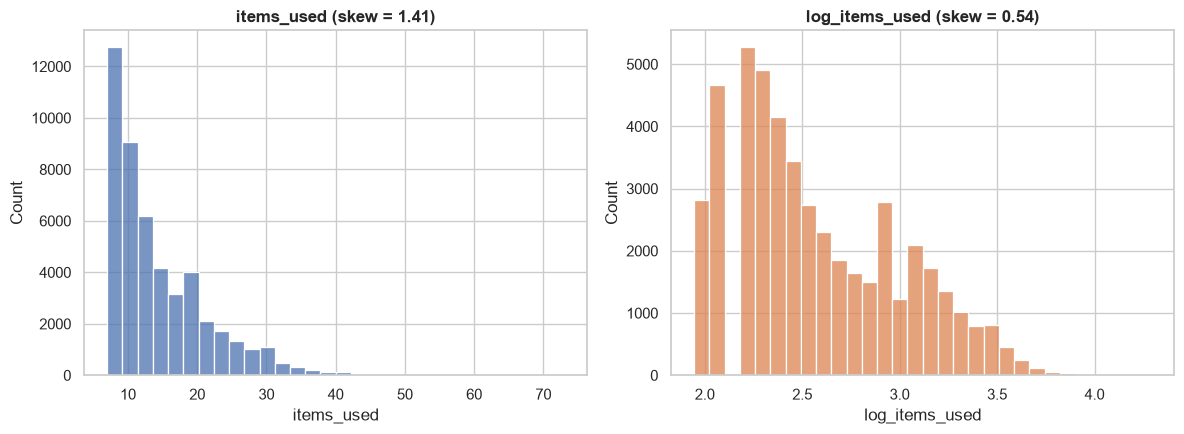

In [33]:

composting["log_items_used"] = np.log(composting["items_used"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=False)
sns.histplot(composting["items_used"], bins=30, ax=axes[0])
axes[0].set_title(f"items_used (skew = {composting['items_used'].skew():.2f})")
sns.histplot(composting["log_items_used"], bins=30, ax=axes[1], color="#DD8452")
axes[1].set_title(f"log_items_used (skew = {composting['log_items_used'].skew():.2f})")
plt.tight_layout()
plt.show()



**Conclusion.** The log transform visibly reduces skew (evidenced by the lower skewness coefficient),
though the combined distribution remains multimodal because it still mixes four different tiers — the log
transform addresses skew *within* a material's distribution, not the separation *between* materials, which
is why `probability_tier` remains necessary as a separate feature.


### Summary of engineered variables

| Variable | Type | Built from | Purpose |
|---|---|---|---|
| `level_increased` | binary | reconstructed attempt-level table (Section 8) | primary target, matching the course's stated task |
| `p_hat` | numeric, continuous, per material | `mean(level_increased)` per material | interpretable estimate of each material's per-attempt success probability |
| `quick_fill_10`, `quick_fill_20` | binary | `items_used` + a fixed budget `K` | secondary, session-level candidate target |
| `probability_tier` | categorical, ordinal (4 levels) | gaps in per-material mean `items_used` | low-cardinality, data-driven replacement for 16-level `material` |
| `is_seed` | binary | material name | cheap semantic grouping; shown to be largely redundant with `probability_tier` |
| `log_items_used` | numeric, continuous | `log(items_used)` | variance-stabilizing transform for regression framings |


### Feature redundancy audit: what to keep vs. drop for modeling

Sections 9–10 already showed, qualitatively, that several of these variables overlap. Here we quantify that
overlap directly — with Cramér's V for pairs of categorical variables, and Spearman correlation for the two
numeric variables — and turn it into an explicit keep/drop recommendation, since "should this go into the
model" is exactly the question an EDA is supposed to answer before modeling starts.


In [34]:

def cramers_v(a, b):
    table = pd.crosstab(a, b)
    chi2, p, dof, expected = stats.chi2_contingency(table)
    n = table.sum().sum()
    r, k = table.shape
    return np.sqrt((chi2 / n) / (min(r - 1, k - 1)))

categorical_pairs = [
    ("material", "probability_tier"),
    ("material", "is_seed"),
    ("probability_tier", "is_seed"),
]
assoc_rows = [
    {"pair": f"{a} vs {b}", "cramers_v": cramers_v(composting[a], composting[b])}
    for a, b in categorical_pairs
]
categorical_assoc = pd.DataFrame(assoc_rows)

numeric_corr = pd.DataFrame({
    "pair": ["items_used vs log_items_used"],
    "pearson_r": [composting["items_used"].corr(composting["log_items_used"])],
    "spearman_rho": [composting["items_used"].corr(composting["log_items_used"], method="spearman")],
})

display_categorical = categorical_assoc.copy()
print("Categorical-categorical association (Cramer's V, 0 = independent, 1 = fully determined):")
display_categorical


Categorical-categorical association (Cramer's V, 0 = independent, 1 = fully determined):


,pair,cramers_v
0,material vs probability_tier,1.000
1,material vs is_seed,1.000
2,probability_tier vs is_seed,0.745


In [35]:

print("Numeric-numeric correlation (items_used vs. its own log transform):")
numeric_corr


Numeric-numeric correlation (items_used vs. its own log transform):


,pair,pearson_r,spearman_rho
0,items_used vs log_items_used,0.972,1.000



**Conclusion.** `material` vs. `probability_tier` and `material` vs. `is_seed` both sit at (or effectively
at) the maximum possible Cramér's V — expected, since both are deterministic functions of `material` by
construction, not independently discovered associations. `probability_tier` vs. `is_seed` is high but not
maximal, matching the Section 10 finding that `is_seed` only varies *within* the "Slow fill" tier.
`items_used` and `log_items_used` are perfectly rank-correlated (Spearman ρ = 1, since the log transform is
monotonic) and very highly Pearson-correlated. None of this is a surprising discovery — it is exactly what
redundancy looks like when variables are built from each other — but stating it numerically, rather than
only visually, is what turns "these seem related" into "these should not both be fed to a model as if they
were independent evidence."

**Keep vs. drop recommendation:**

| Variable | Redundant with | Evidence | Recommendation |
|---|---|---|---|
| `material` | `probability_tier` | Cramér's V at maximum (deterministic mapping); eta-squared retained 99.9% (Section 10) | Pick **one**. Prefer `probability_tier` for a lower-cardinality encoding; keep `material` only if the extra granularity is later shown to matter. |
| `is_seed` | `material` / `probability_tier` | High Cramér's V; adds no separation within tiers (Section 10 interaction check) | **Drop** if `material` or `probability_tier` is already included — confirmed redundant, not just suspected. |
| `log_items_used` | `items_used` | Spearman ρ = 1 (deterministic transform) | Pick **one**, not both. Use `log_items_used` for linear/regression models sensitive to skew; irrelevant for tree-based models. |
| `items_used`, `log_items_used`, `quick_fill_10`, `quick_fill_20` | each other | `quick_fill_*` is a threshold *applied to* `items_used` | **Never combine as features** — whichever of these is chosen as the target, the others encode it directly and must be excluded from the feature set (textbook leakage, not a subtle case). |
| `items_used`, `log_items_used` | `level_increased` | `items_used` is a *session-level* total only knowable after the session ends | **Exclude** when predicting `level_increased` for a single attempt — using it would leak information from the future (the eventual session length) into a prediction that should only see the current attempt. |
| `trial_id`, `session_id`, `attempt_number` | — | identifiers; `attempt_number` order is synthetic (Section 8) | **Exclude entirely.** These carry no measured signal — `attempt_number` in particular was fabricated by our own random placement, not observed. |

For the course's actual target, `level_increased`, this leaves a blunt but honest conclusion: **`material`
(or `probability_tier`) is essentially the only legitimate predictor available in this dataset.** That is not
a modeling failure — it is a direct, quantified consequence of how the data was generated, and worth stating
plainly rather than padding the feature list with variables that are either redundant or leak the target.


### Exporting the engineered dataframe(s)

`data/composting_combined.csv` (built prior to this notebook, loaded in Section 4) is the single base file this entire notebook has been
working from — `material`, `trial_id`, `items_used`, nothing more. Since then, this notebook has added
engineered columns on top of it (`quick_fill_10/20`, `probability_tier`, `is_seed`, `log_items_used`) and
built a second, attempt-level table (`attempts`, Section 8). For convenience — so a later modeling notebook
can start from a fully-featured file instead of re-deriving every column — we also materialize both
**enriched** results as their own CSVs. These are additional, derived outputs on top of the one base file;
they do not replace it, and neither the 16 raw per-material files nor `composting_combined.csv` are
overwritten.


In [36]:

features_export_path = DATA_DIR / "composting_features.csv"
composting.to_csv(features_export_path, index=False)
print(f"Engineered session-level dataframe written to: {features_export_path.resolve()}")
print(f"Shape: {composting.shape[0]:,} rows x {composting.shape[1]} columns")
composting.dtypes.to_frame("dtype")


Engineered session-level dataframe written to: C:\Users\redon\Desktop\projects\minecraft_composting_success_predictor\data\composting_features.csv
Shape: 48,000 rows x 8 columns


,dtype
material,str
trial_id,int64
items_used,int64
quick_fill_10,int64
quick_fill_20,int64
probability_tier,category
is_seed,str
log_items_used,float64


In [37]:

attempts_export_path = DATA_DIR / "composting_attempts.csv"
attempts.to_csv(attempts_export_path, index=False)
print(f"Unified attempt-level dataframe written to: {attempts_export_path.resolve()}")
print(f"Shape: {attempts.shape[0]:,} rows x {attempts.shape[1]} columns")
attempts.dtypes.to_frame("dtype")


Unified attempt-level dataframe written to: C:\Users\redon\Desktop\projects\minecraft_composting_success_predictor\data\composting_attempts.csv
Shape: 695,423 rows x 4 columns


,dtype
material,str
session_id,int64
attempt_number,int64
level_increased,int64



**Conclusion.** `composting_features.csv` carries every column engineered above (material, `items_used`,
both `quick_fill` thresholds, `probability_tier`, `is_seed`, `log_items_used`), and `composting_attempts.csv`
carries the attempt-level reconstruction (`material`, `session_id`, `attempt_number`, `level_increased`)
discussed in Section 8, including its synthetic-order caveat. Anyone loading either CSV directly should
still read Sections 4 and 8 to understand what each column means and which ones (`items_used`,
`attempt_number`) are not safe to use as model features, per the redundancy audit above.



# 12. Conclusions, Limitations, and Roadmap

**Main findings**
- The combined session-level dataset is clean: no missing values, no duplicate identifiers, all values
  above the theoretical minimum of 7, and a perfectly balanced design (3,000 trials × 16 materials).
- `items_used` is right-skewed overall and, per material, materials fall into **4 clearly separated
  behavioral tiers** rather than varying individually or continuously. Quantitatively, `probability_tier`
  (4 levels) retains over 99.9% of the variance in `items_used` that the full 16-level `material` explains
  (eta-squared 0.5515 vs. 0.5516), and materials within a tier also match on relative variability
  (coefficient of variation) — two independent confirmations that the tier grouping is a safe,
  low-cardinality stand-in for `material`.
- **The raw data's granularity (session totals) does not match the course's stated prediction unit
  (individual attempts).** We reconstructed the attempt-level table in Section 8 under an explicit,
  documented assumption (uniform placement of the 6 non-terminal successes within a session), validated it
  (every session sums to exactly 7 successes), and confirmed it adds no new information beyond what the
  session-level means already implied — it only reshapes the data into the correct unit.
- **The "class balance" of this problem depends entirely on which granularity is used**: the attempt-level
  target `level_increased` is nearly balanced (≈ 48% / 52%), while the session-level `quick_fill_20` target
  is heavily imbalanced (≈ 82% / 18%). Neither number is "the" class balance of "this dataset" — it depends
  on the unit of observation chosen, which is itself a modeling decision.
- A row-order check found no drift or sequence effect within any material's 3,000 trials (all correlations
  with `trial_id` within ±0.09), supporting the i.i.d. assumption the reconstruction in Section 8 relies on.
- `is_seed` is a cheap but largely redundant grouping once `probability_tier` (or `material`) is known.

**Data quality issues to carry forward**
- None require cleaning or imputation in the raw session-level files — no missing values, impossible
  values, or duplicate keys. The main "issue" is conceptual: repeated `items_used` values across rows are
  legitimate and must not be mistaken for duplicated observations.

**Potentially important variables and interactions**
- `probability_tier` is a strong candidate to replace or supplement raw `material` as a lower-cardinality
  predictor, for either target.
- `log_items_used` is worth carrying into a regression framing of `items_used`.
- The tier × seed interaction examined earlier in Section 10 showed redundancy rather than added signal — worth
  re-checking once more features (if any) become available.

**Limitations, biases, and open questions**
- The dataset is **entirely synthetic**: every trial is complete by construction, so this EDA cannot speak
  to real-world missingness, measurement error, or non-stationarity.
- The attempt-level table (Section 8) has **synthetic within-session ordering**: only the total count per
  session was observed, not the actual sequence of successes and failures. Any feature depending on that
  reconstructed order (e.g., "attempts since the last failure") would be fabricated, not measured, and must
  not be used as if it were real signal.
- Under either target, **`material` is almost sufficient on its own to predict success**: `p_hat` is a
  near-deterministic function of `material`, and `quick_fill_20` is nearly so as well. If `material` is
  always known at prediction time, a classifier essentially only needs to relearn each material's fixed
  probability — a near-lookup rather than a rich learning problem. A more interesting task would need
  features not present here (e.g., current composter level, or attempt history within a session) — but
  building those honestly (not synthetically, as in Section 8) would require different raw data than what
  is available.
- The `K = 10` / `K = 20` budgets for `quick_fill` are illustrative choices, not validated requirements; the
  right budget depends on the actual downstream use case and should be revisited before modeling.

**Hypotheses to validate during modeling**
- Start from the exported `data/composting_attempts.csv` (attempt level) for the target task, or
  `data/composting_features.csv` (session level, fully engineered) for the secondary framing — both are
  byproducts of this notebook's own feature-engineering and reconstruction logic, not new files from elsewhere.
- Train the logistic regression baseline on the **attempt-level** table from Section 8, since that is the
  unit the stated task is defined on — not on session aggregates.
- Follow the redundancy audit above: do not feed `material` and `probability_tier` (or `is_seed`) to the
  same model as if they were independent evidence, and never include `items_used` / `log_items_used` /
  `quick_fill_*` alongside whichever of them is chosen as the target.
- Encode `material` via `probability_tier` (4 levels) rather than one-hot over all 16 levels, and check
  whether it costs meaningful predictive performance.
- If a regression framing is used for `items_used`, fit on `log_items_used` and back-transform.
- Any imputer, encoder, scaler, or feature selection step must be fit **only on the training split** to
  avoid data leakage — although this dataset has no missing values today, this still applies to any
  encoding/scaling estimated from the data (e.g., tier boundaries, if re-derived per split).
- Evaluate a plain "majority class per material" (or per tier) baseline before crediting any model with
  genuine predictive skill, given how strongly `material` alone determines both targets.
